<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Tomás Vallejo Cerda 
- Nombre de alumno 2:


### **Link de repositorio de GitHub:** `http://....`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [42]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [43]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [44]:
# Revisamos los tipos de datos de cada columna
df_retail_1.dtypes

Invoice        category
StockCode      category
Description         str
Quantity          int64
Price           float64
Customer ID    category
Country          object
dtype: object

In [45]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")

df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [46]:
# Revisamos los tipos de datos de cada columna
df_retail_2.dtypes

Invoice              category
InvoiceDate    datetime64[ns]
dtype: object

Vemos que las columnas de tipo correctas para ambos dataframes

In [47]:
# Combinamos ambos DataFrames
df_combinado = pd.merge(df_retail_1, df_retail_2, on="Invoice", how="left")

df_combinado.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


Debemos utilizar una función tipo merge, ya que ambos datasets comparten una columna clave en común (Invoice) analizando nos damos cuenta que df_retail_1 contiene el detalle de cada producto vendido mientras que df_retail_2 contiene la fecha de cada boleta. Entoces, la combinación correcta es un left merge lo que añade el InvoiceDate como última columna a cada fila de productos vendido. 

In [48]:
df_combinado.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  category      
 1   StockCode    525461 non-null  category      
 2   Description  522533 non-null  str           
 3   Quantity     525461 non-null  int64         
 4   Price        525461 non-null  float64       
 5   Customer ID  417534 non-null  category      
 6   Country      525461 non-null  object        
 7   InvoiceDate  525461 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(1), str(1)
memory usage: 24.5+ MB


Columnas del Dataset:
- Invoice: category - Número identificador de la boleta
- Stockcode: category - Código único del producto
- Description: str - Nombre/descripción del producto
- Quantity: int64 - Cant. de unidades de producto en la venta
- Price: float64 - Precio unitario del producto
- Customer ID: category - Identificador único del cliente 
- Country: object - País donde se realizó la compra
- InvoiceDate: datatime64[ns] - fecha y hora en que se generó a boleta

Cabe estacar que de inmediato veamos datos faltantes en sólo dos columnas (Customer ID y Description) 

## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

El análisis univariado como lo dice su nombre estudia cada variable de forma individual (distribución,media,outliers,nulos,etc). mientras que el multivariado examina la relación entre dos o más variables, aqui vemos calculos como correlaciones, patrones. El análisis de datos faltantes corresponde a identificar que columnas y en que proporción presentan valores nulos, teniendo que tomar la decisión según el caso de imputarlos (con alguna técnica adecuada al caso) o eliminarlos. los beneficios son variados, desde detectar valores erróneos, sesgo, anomalías,etc. Pudiendo evitar que datos sucios contaminen el estudio

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [49]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [50]:
profile_serie(df_combinado["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

La mayoría de los productos tiene precio bajo (mediana = 2.1), se observa la anomalía de 3 precios negativos y 3.687 precios que son cero, algo que resulta imposible en un contexto de ventas (hay que estudiar que sucede). Hay outliers muy severos como el min muy negativo y el máximo muy positivo. el -53.594 arrastra la la distribución. 

In [51]:
profile_serie(df_combinado["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

Vemos que la mayoría de las ventas son cantidades pequeñas. (mediana = 3), algo que llama la atención es que hay 12.326 valores negativos (2,35%) que supongo que corresponden a devoluciones. Existen outliers que parecen ser anómalos como el -9.600 o el 19.152, sin estos el grueso se concentra entre 20 y 25 unidades.

In [52]:
profile_serie(df_combinado["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

Vemos que existen 28.816 boletas únicas, el pocentaje de duplicado es muy alto (98.48%) algo esperable iual ya que cada boleta se repite tantas veces como productos contenga. al boleta con mayor frecuencia es la 537434 lo que podría indicar un pedido muy grande (mayorista).

In [53]:
profile_serie(df_combinado["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

Los registros cubren aprox 1 año de ventas, no existen valores nulos lo que habla muy bien de la trazabilidad de cada boleta. Se ve un aumento de frecuencia en las fechas de fin de año, algo esperable por fechas especiales de mucho consumo.

In [54]:
profile_serie(df_combinado["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

Existen 4.632 productos únicos. El código más frecuente es el 85123A con 3.516 apariciones, además se observan códigos extraños como POST,M y DOT que probablemente no sean productos reales, algo digno a estudiar.

In [55]:
profile_serie(df_combinado["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

Tiene un 0,56% de nulos y 4.681 descripciones únicas. El prodcuto estrella es el "WHITE HANGING HEART T-LIGHT HOLDER". podemos ver que parecen dominar productos de tipo para el hogar o decorativo.

In [56]:
profile_serie(df_combinado["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

Esta columna es la con mayor problema, tiene 107.927 valores nulos que equivale a un 20.54%. Ósea que existe casi un 21% de ventas sin registro de quién fue el cliente. El cliente más frecuente tiene 5.710 transacciones, debe ser un mayorista.Sólo se tienen 4.383 clientes únicos.

In [57]:
profile_serie(df_combinado["Country"])

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

Está fuertemente dominado por Reino Unido con 485.852 registros lo que es un 92% del total. Llama la atención también una categoría "Unspecified" que debe representar compras sin país identificado, lo que se podría considerar para limpiar pero se ve muy poco igualmente.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [58]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

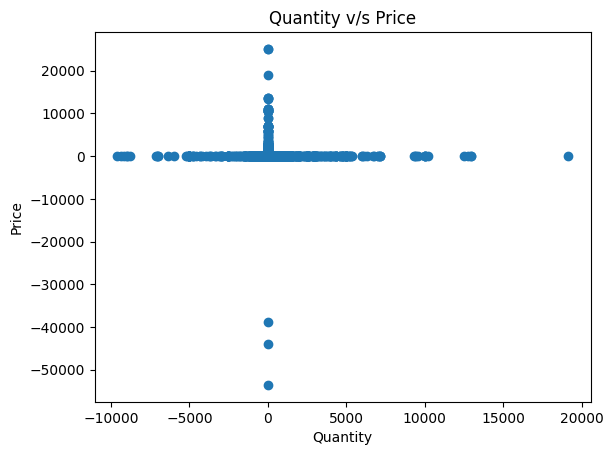

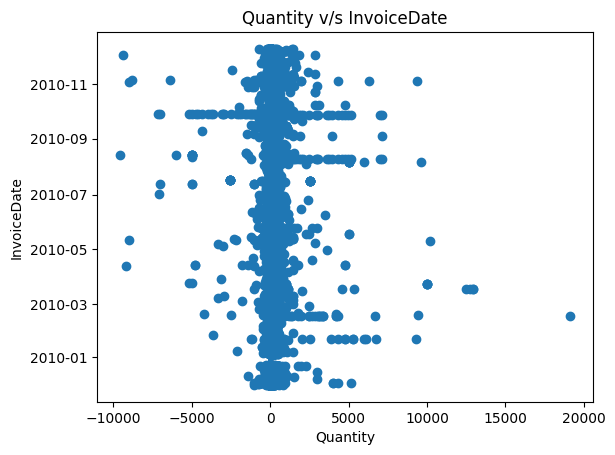

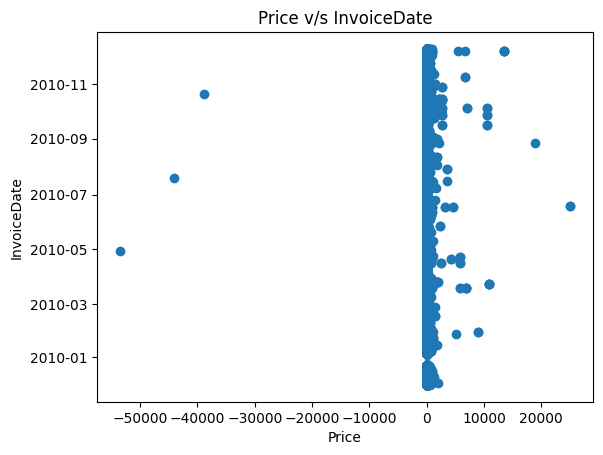

## Correlation:

## Missing Matrix:

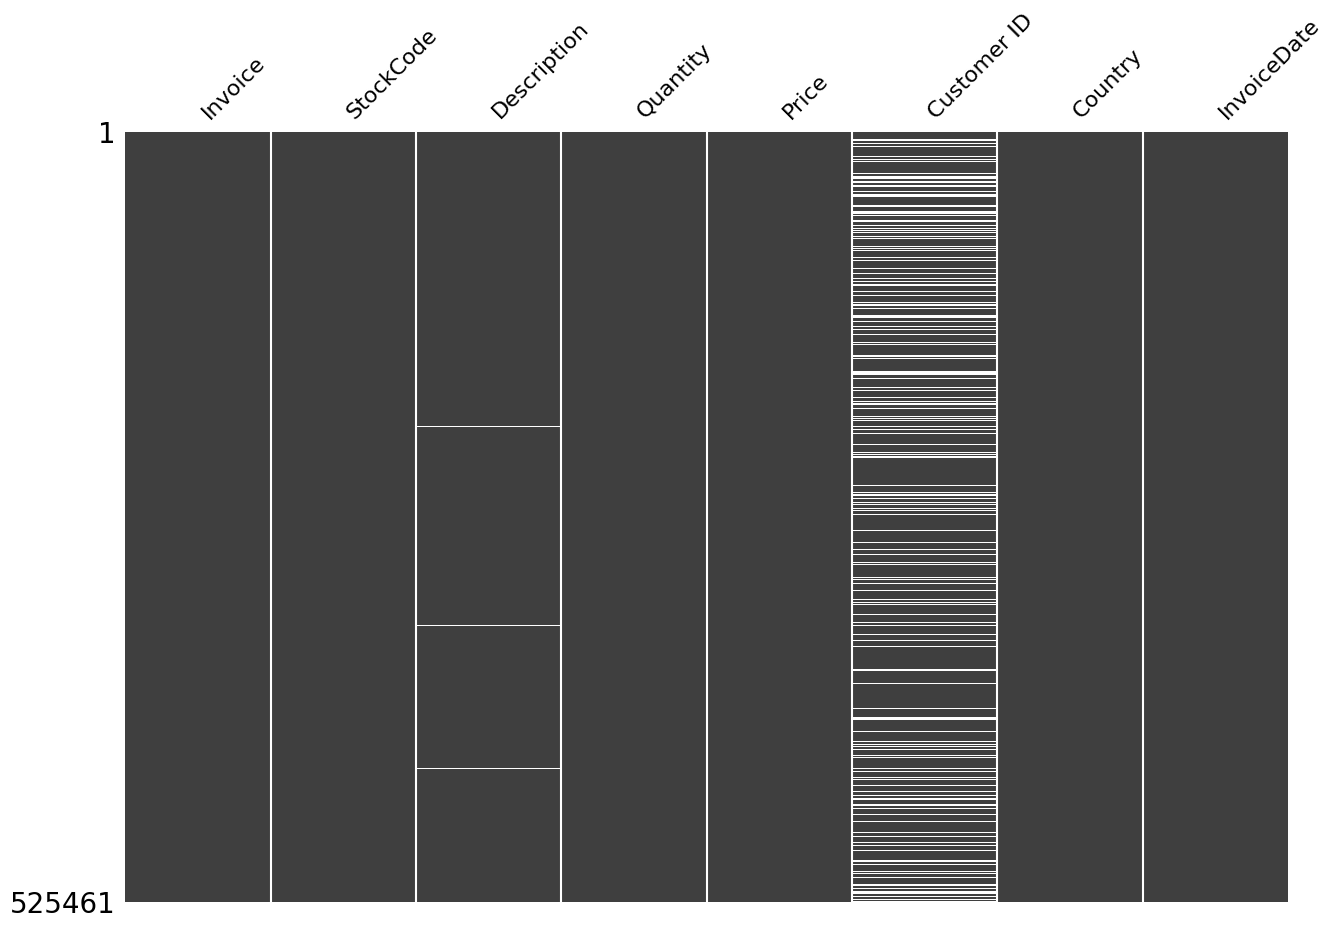

In [59]:
profile_df(df_combinado)

Los gráficos dejan en evidencia los outliers que vimos anteriormente. En Quntity vs Price se aprecia una forma de cruz caracteristico de valores extremos en cada eje, precios negativos y cantidades negativas. Junto con el gráfico de Price vs InvoiceDate se cnfirma que los precios negativos son 3 casos puntuales y aislados, por lo que no supone un problema sistemático. Con respecto a las correlaciones, la matriz no aporta y no se ven correlaciones claras entre las variables. Finalemente en la matriz de datos faltantes se visualiza y confirma lo visto antes, Customer ID tiene bastantes nulos distribuidos de forma uniforme a lo largo de todo el dataset, mientras que Description tiene unos pocos nulos en zonas específicas.

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [60]:
def limpiar_datos(df):
    # Realizamos una copia del DataFrame combinado para limpiar los datos y no alterar el original
    df_clean = df.copy()

    # Eliminamos precios y cantidades negativas y ceros
    df_clean = df_clean[(df_clean["Price"] > 0) & (df_clean["Quantity"] > 0)]

    # Eliminamos outliers en Price y Quantity utilizando el método del Z-score (considerando un umbral de 3 consistente con la formulación de profile_serie)
    df_clean = df_clean[
        (np.abs(stats.zscore(df_clean["Price"])) < 3) & (np.abs(stats.zscore(df_clean["Quantity"])) < 3)
    ]

    # Eliminamos filas con Description nula (0,56% de los datos)
    df_clean = df_clean[df_clean["Description"].notna()]

    print(f"filas originales: {len(df_combinado)}")
    print(f"filas después de limpiar: {len(df_clean)}")
    print(f"filas eliminadas: {len(df_combinado) - len(df_clean)}")
    print(
        f"porcentaje de filas eliminadas: {round((len(df_combinado) - len(df_clean)) / len(df_combinado) * 100, 2)} %"
    )

    return df_clean

In [61]:
df_limpio = limpiar_datos(df_combinado)

filas originales: 525461
filas después de limpiar: 509456
filas eliminadas: 16005
porcentaje de filas eliminadas: 3.05 %


Cabe destacar que con respecto a la variable Customer ID, se identificó un porcentaje cercano al 20% de valores faltantes. No obstante, se decidió no eliminar estos registros ni imputar valores artificiales u otra medida, ya que la eliminación implicaría una pérdida considerable de información transaccional válida (como precios, cantidades y fechas), afectando la representatividad del dataset. Por otro lado, la imputación no resulta adecuada, ya que el Customer ID corresponde a un identificador único y no a una variable inferible a partir de otras, por lo que cualquier asignación introduciría errores y sesgos. Dado que el enfoque de este estudio se centra en el comportamiento general de las transacciones y no en el análisis individual de clientes, la ausencia de este identificador no impacta de manera significativa los resultados. Por ello, se opta por mantener estos registros, asegurando la integridad del volumen de datos y evitando introducir supuestos incorrectos.

## EDA Dataset limpio

In [62]:
profile_serie(df_limpio["Price"])

## Price Profile

Type                            float64
Number of observations         509456.0
Mean                            3.53497
Std                            5.280004
Min                               0.001
25%                                1.25
50%                                 2.1
75%                                4.21
Max                              195.22
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                         339.428012
Skew                          13.625068
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   508894
Duplicate rows (%)              99.89 %
Total size in memory      8151296 bytes
dtype: object

In [63]:
profile_serie(df_limpio["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         509456.0
Mean                            8.96922
Std                           18.354661
Min                                 1.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                               271.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                          55.355607
Skew                            6.39254
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   509420
Duplicate rows (%)              99.99 %
Total size in memory      8151296 bytes
dtype: object

In [64]:
profile_serie(df_limpio["Invoice"])

## Invoice Profile

Type                           category
Number of observations           509456
Unique                            20562
Top                              537434
Freq                                674
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   507609
Duplicate rows (%)              99.64 %
Total size in memory      6381896 bytes
dtype: object

In [65]:
profile_serie(df_limpio["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           509456
Mean                      2010-06-28 23:55:02.560142336
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 15:36:00
50%                                 2010-07-07 09:49:00
75%                                 2010-10-15 16:00:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   507909
Duplicate rows (%)                               99.7 %
Total size in memory                      8151296 bytes
dtype: object

In [66]:
profile_serie(df_limpio["StockCode"])

## StockCode Profile

Type                           category
Number of observations           509456
Unique                             4245
Top                              85123A
Freq                               3397
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   509283
Duplicate rows (%)              99.97 %
Total size in memory      5263752 bytes
dtype: object

In [67]:
profile_serie(df_limpio["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         405861.0
Unique                           4283.0
Top                             14911.0
Freq                             5551.0
                                       
Missing cells                    103595
Missing cells (%)               20.33 %
Duplicate rows                   509372
Duplicate rows (%)              99.98 %
Total size in memory      5129624 bytes
dtype: object

In [68]:
profile_serie(df_limpio["Country"])

## Country Profile

Type                              object
Number of observations            509456
Unique                                40
Top                       United Kingdom
Freq                              471777
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    509456
Duplicate rows (%)               100.0 %
Total size in memory       8151296 bytes
dtype: object

In [69]:
profile_serie(df_limpio["Description"])

## Description Profile

Type                                                     str
Number of observations                                509456
Unique                                                  4527
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3431
                                                            
Missing cells                                              0
Missing cells (%)                                      0.0 %
Duplicate rows                                        509277
Duplicate rows (%)                                   99.96 %
Total size in memory                           8151296 bytes
dtype: object

Tras la limpieza de los datos, el conjunto presenta un comportamiento mucho más coherente y representativo de las transacciones reales. En Price se reduce el sesgo observado inicialmente, concentrando la distribución en rangos bajos y manteniendo una asimetría positiva, pero sin los outliers extremos que dificultaban su interpretación. De forma similar, en Quantity se logra una distribución más enfocada en compras pequeñas, típicas del comportamiento minorista, aunque aún se conservan algunos valores altos que pueden atribuirse a compras al por mayor. En cuanto a los demás parámetros no se observan cambios estructurales relevantes, siguen sus tendencias pero actualmente gracias a la limpieza sin la interferencia de datos erróneos.

## Bivariant Analysis:

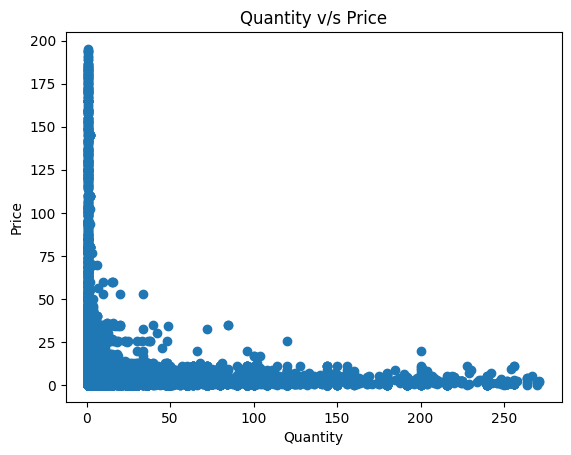

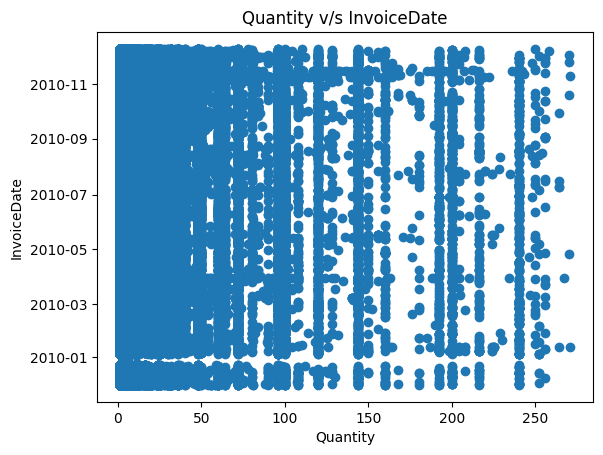

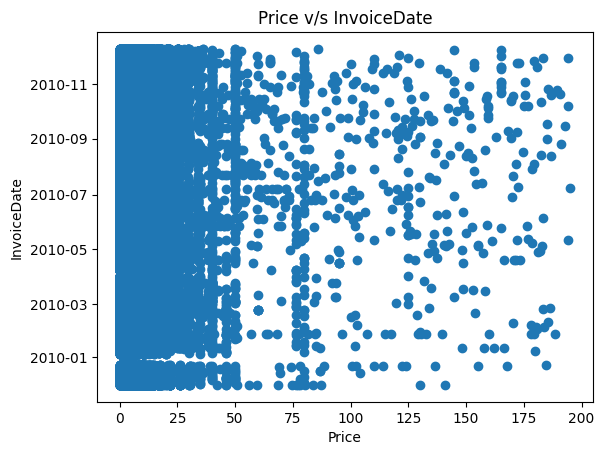

## Correlation:

## Missing Matrix:

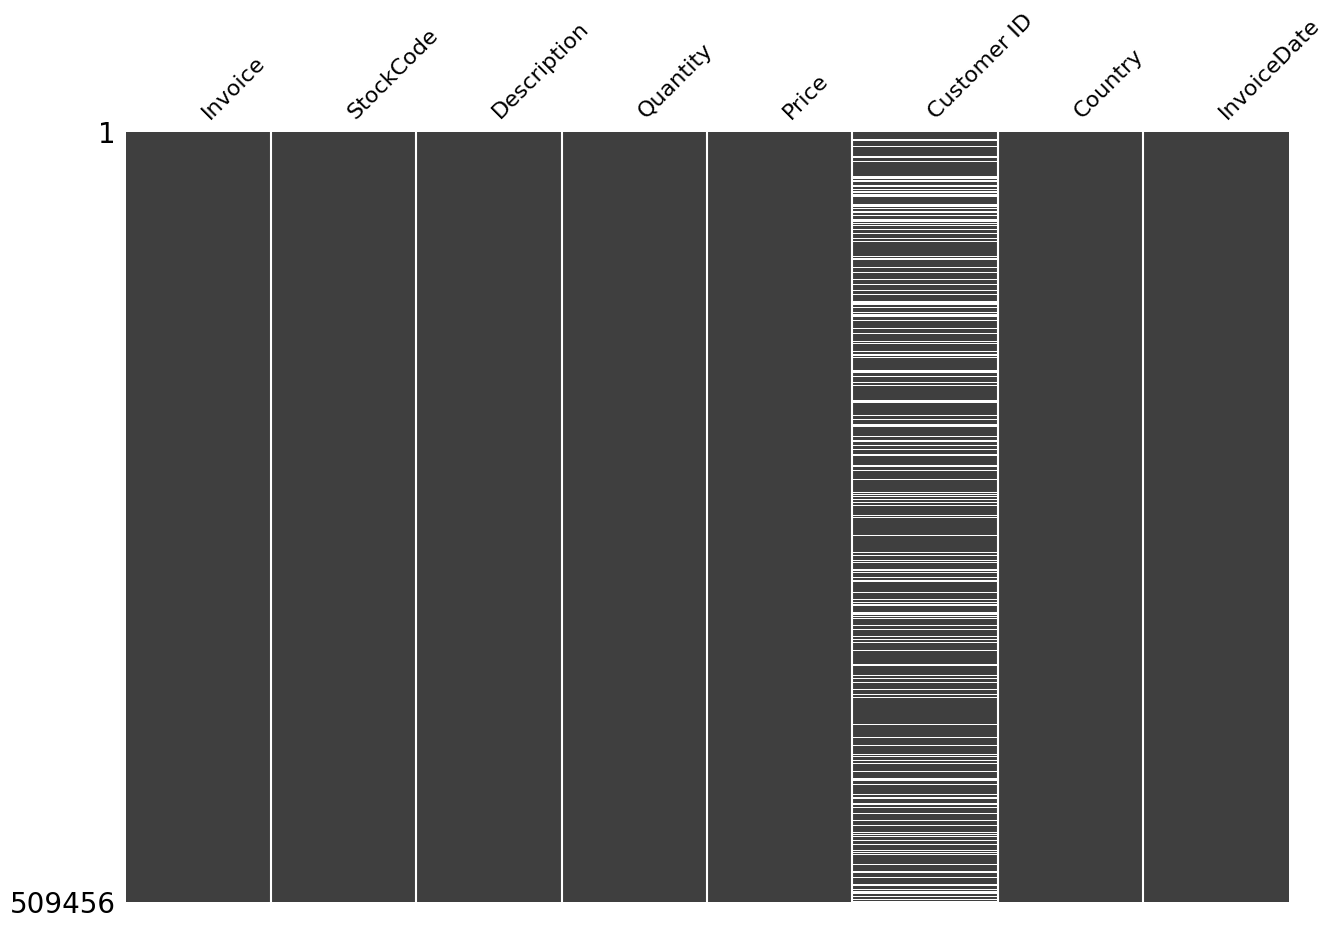

In [70]:
profile_df(df_limpio)

Vemos que las correlaciones ahora cambian bastante entre los datos debido a la limpieza, ahora si ver un claro patrón en "L" de Quantity vs Price que gracias a quitar los outliers y negativos se puede observar el comportamiento esperado, donde lo que más se vende es de precio bajo tendiendo a cero y disminuye al aumentar el precio de manera brusca. En los otras dos graficas de InvoiceDate vs Price y Quantity ahora si se puede observar lo esperado de los análisis. En la matriz de correalción se puede observar que ahora si existen correlaciones donde se correlacionan InvoiceDate con Quantity y Price lo esperado del análisis también. No se observa fuerte correlación entre Price y Quantity, esto es completamente normal y esperado en este modelo de negocio, ya que el precio de un artículo no determina de forma lineal o proporcional cuántas unidades se comprarán.

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [71]:
# Crear la columna de Ingresos (Ingreso = Precio x Cantidad)
df_limpio["Ingreso"] = df_limpio["Quantity"] * df_limpio["Price"]

# 2. Agrupar por StockCode
df_productos = df_limpio.groupby("StockCode", as_index=False).agg(
    Total_Ingreso=("Ingreso", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Description=("Description", "first"),  # Rescata el primer nombre válido que encuentre
)

# Obtener el Top 30 por Ganancias y por Volumen
top_30_ganancias = df_productos.sort_values(by="Total_Ingreso", ascending=False).head(30)
top_30_cantidad = df_productos.sort_values(by="Total_Quantity", ascending=False).head(30)

# Gráfico TOP 30 por Cantidad
fig_cantidad = px.bar(top_30_cantidad, x="Description", y="Total_Quantity", title="Top 30 Productos más Vendidos")
fig_cantidad.update_layout(xaxis_tickangle=-45)
fig_cantidad.show()

# Graficos TOP 30 por Ganancias
fig_ganancias = px.bar(
    top_30_ganancias, x="Description", y="Total_Ingreso", title="Top 30 Productos con Mayores Ganancias"
)
fig_ganancias.update_layout(xaxis_tickangle=-45)
fig_ganancias.show()

In [72]:
# Queremos ver cuántos productos se repiten en ambas listas
mas_vendidos = top_30_cantidad["Description"].tolist()
mas_ganancia = top_30_ganancias["Description"].tolist()

# 2. Usamos la intersección de conjuntos (matemática pura) para ver cuáles se repiten
productos_comunes = set(mas_vendidos).intersection(set(mas_ganancia))

len(productos_comunes)

11

Los artículos más vendidos NO coinciden exactamente con los que generan mayores ganancias, es algo de esperar en el mundo del retail (depende que retail igual), donde no necesariamente lo más vendido reporta las mayores ganancias al negocio, por ejemplo tenemos que el producto más vendido en cantidad "PACK OF 72 RETRO SPOT CAKE CASES" en términos de ganancia se ubica en el puesto 29°. Igualmente cabe destacar que existe correlación clara donde el 2°,3° y 4° de ambos TOP coinciden y en total 11 de los productos más vendidos están tambien en los con mayor ganancia para el retail.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [77]:
def plot_ventas(dataframe):
    # Agrupar por fecha y sumar la CANTIDAD de productos vendidos
    ventas_diarias = dataframe.groupby("InvoiceDate", as_index=False)["Quantity"].sum()

    # Grafico de línea para mostrar la evolución del volumen de ventas diarias
    fig = px.line(
        ventas_diarias,
        x="InvoiceDate",
        y="Quantity",
        title="Evolución del Volumen de Ventas Diarias",
        labels={"Date": "Fecha", "Quantity": "Cantidad de Artículos Vendidos"},
    )

    fig.update_layout(xaxis_tickangle=-45)

    return fig


def plot_ingresos(dataframe):
    # Agrupar por fecha y sumar la CANTIDAD de productos vendidos
    ventas_diarias = dataframe.groupby("InvoiceDate", as_index=False)["Ingreso"].sum()

    # Grafico de línea para mostrar la evolución del volumen de ventas diarias
    fig = px.line(
        ventas_diarias,
        x="InvoiceDate",
        y="Ingreso",
        title="Evolución del Volumen de Ingreso Diario",
        labels={"Date": "Fecha", "Ingreso": "Ingresos Totales"},
    )

    fig.update_layout(xaxis_tickangle=-45)

    return fig

In [78]:
fig_ventas = plot_ventas(df_limpio)
fig_ventas.show()

fig_ventas = plot_ingresos(df_limpio)
fig_ventas.show()

Al observar los gráficos, queda claro que el volumen de artículos y los ingresos se mueven a la par (lo esperable). Lo más destacable, y el principal dato atípico que rompe la tendencia del año, es la brutal explosión de ventas que ocurre en el último trimestre, alcanzando su punto máximo entre noviembre y mediados de diciembre debido a las compras de fin de año y festividades como navidad. Inmediatamente después de esa locura de ventas la línea se desploma, lo cual tiene todo el sentido del mundo en el mundo del retail, en especial para este tipo.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>